In [43]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import SOCK

# Functions

### Data

In [2]:
class JumpDiffusionSimulator:
    """Simulates a multivariate Merton-style Jump Diffusion process."""
    def __init__(self, d: int, mu: float = 0.05, sigma: float = 0.2, 
                 jump_intensity: float = 5.0, jump_mean: float = 0.0, jump_std: float = 0.3):
        self.d = d
        self.mu = mu
        self.sigma = sigma
        self.jump_intensity = jump_intensity
        self.jump_mean = jump_mean
        self.jump_std = jump_std

    def simulate(self, H: int, dt: float = 1/252) -> torch.Tensor:
        """Generates a single historical path of length H."""
        # Standard Brownian motion
        dW = torch.randn(H, self.d) * math.sqrt(dt)
        
        # Poisson jump process
        n_jumps = torch.poisson(torch.ones(H, self.d) * self.jump_intensity * dt)
        J = n_jumps * torch.randn(H, self.d) * self.jump_std + n_jumps * self.jump_mean
        
        # Log returns
        returns = (self.mu - 0.5 * self.sigma**2) * dt + self.sigma * dW + J
        
        # Convert returns to price paths (normalized to start at 1.0), then take log
        prices = torch.exp(torch.cumsum(returns, dim=0))
        return torch.log(prices)

class FinancialTimeSeriesDataset(Dataset):
    """Extracts sliding windows (context q, horizon T) and standardizes data."""
    def __init__(self, path: torch.Tensor, q: int = 5, T: int = 64):
        self.path = path
        self.q = q
        self.T = T
        self.H, self.d = path.shape
        
        # Standardize using the raw training path 
        self.mean = self.path.mean(dim=0, keepdim=True)
        self.std = self.path.std(dim=0, keepdim=True) + 1e-8
        self.scaled_path = (self.path - self.mean) / self.std

    def __len__(self) -> int:
        return self.H - self.q - self.T + 1

    def __getitem__(self, idx: int):
        # Context (x-) and Real Future (x+)
        x_minus = self.scaled_path[idx : idx + self.q]
        x_plus = self.scaled_path[idx + self.q : idx + self.q + self.T]
        return x_minus, x_plus

### Training

In [31]:
def train_sock_generator(
    generator: nn.Module, 
    sock_extractor: nn.Module, 
    dataloader: DataLoader, 
    device: str, 
    total_steps: int = 100000, 
    resample_freq: int = 100
):
    generator.to(device)
    sock_extractor.to(device)
    
    # Optimizer and Scheduler 
    optimizer = torch.optim.AdamW(generator.parameters(), lr=3e-4, weight_decay=0.01)
    
    # Warmup + Decay schedule over total_steps
    warmup_steps = int(0.05 * total_steps)
    
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        return max(0.0, float(total_steps - current_step) / float(max(1, total_steps - warmup_steps)))
        
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    generator.train()
    sock_extractor.fit_ft_scales(dataloader, device)
    
    loss_history = []
    step_count = 0
    data_iter = iter(dataloader)
    
    print(f"Starting training for {total_steps} steps...")
    
    while step_count < total_steps:
        try:
            x_minus, x_plus = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            x_minus, x_plus = next(data_iter)
            
        x_minus, x_plus = x_minus.to(device), x_plus.to(device)
        
        # The Resampling Trick
        if step_count > 0 and step_count % resample_freq == 0:
            sock_extractor.resample()
            sock_extractor.fit_ft_scales(dataloader, device)
        
        optimizer.zero_grad()
        
        # Forward pass
        x_hat_plus = generator(x_minus, T=x_plus.size(1))
        
        # Joined Segments
        real_joined = torch.cat([x_minus, x_plus], dim=1)
        fake_joined = torch.cat([x_minus, x_hat_plus], dim=1)
        
        # Extract Scaled Features
        real_feats = sock_extractor(real_joined, scale=True)
        fake_feats = sock_extractor(fake_joined, scale=True)
        
        # Mean Squared Error on Batch Means
        real_mean = real_feats.mean(dim=0)
        fake_mean = fake_feats.mean(dim=0)
        loss = torch.nn.functional.mse_loss(fake_mean, real_mean)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        loss_history.append(loss.item())
        step_count += 1
        
        if step_count % 1000 == 0:
            print(f"Step {step_count}/{total_steps} | Loss: {loss.item():.6f} | LR: {scheduler.get_last_lr()[0]:.6f}")
            
    return loss_history

# Plotting

In [ ]:
def plot_training_loss(loss_history: list):
    """Visualizes the scaled MSE feature-matching loss over time."""
    plt.figure(figsize=(10, 4))
    plt.plot(loss_history, alpha=0.8, color='blue', linewidth=1.5)
    plt.title("SOCK Feature Matching Loss during Training")
    plt.xlabel("Optimization Steps")
    plt.ylabel("Scaled MSE Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_full_autoregressive_rollout(
    generator: torch.nn.Module, 
    dataset, 
    device: str, 
    path_tensor: torch.Tensor
):
    """
    Plots the full simulated ground truth path alongside a full-length 
    generated path created by autoregressively stitching 64-step chunks together.
    """
    generator.eval()
    
    H, d = path_tensor.shape
    q = dataset.q
    T = dataset.T
    
    # 1. Start with the very first 'q' steps of the scaled real data
    current_context = dataset.scaled_path[:q].unsqueeze(0).to(device) # Shape: (1, q, d)
    
    # We will store our generated chunks here (starting with the initial real context)
    generated_chunks = [current_context.squeeze(0).cpu().numpy()]
    
    steps_generated = q
    
    # 2. Autoregressively generate chunks of length T until we hit H
    with torch.no_grad():
        while steps_generated < H:
            # Generate the next T steps
            next_T = generator(current_context, T=T) # Shape: (1, T, d)
            
            # Store the generated chunk
            generated_chunks.append(next_T.squeeze(0).cpu().numpy())
            steps_generated += T
            
            # Update context for the next loop: use the last 'q' steps of the generated chunk
            current_context = next_T[:, -q:, :]
            
    # 3. Stitch chunks together and trim to exact length H
    full_generated_scaled = np.concatenate(generated_chunks, axis=0)[:H]
    
    # 4. Un-standardize the generated path back to the original price scale
    mean = dataset.mean.squeeze().cpu().numpy()
    std = dataset.std.squeeze().cpu().numpy()
    full_generated = full_generated_scaled * std + mean
    
    # Convert real path to numpy
    path_np = path_tensor.cpu().numpy()
    
    # 5. Plotting
    plt.figure(figsize=(12, 6))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Standard plotting colors
    
    # Plot Real Assets (Solid Lines)
    for i in range(d):
        plt.plot(path_np[:, i], label=f'Real Asset {i+1}', 
                 linewidth=2.0, alpha=0.8, color=colors[i])
        
    # Plot Generated Assets (Dashed Lines)
    for i in range(d):
        plt.plot(full_generated[:, i], label=f'Generated Asset {i+1}', 
                 linewidth=1.5, alpha=0.9, linestyle='--', color=colors[i])
        
    plt.title(f"Full Path Comparison: Ground Truth vs. Autoregressive Generation (H={H} steps)")
    plt.xlabel("Time Steps (Trading Days)")
    plt.ylabel("Log Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Execution

In [33]:
def seed_everything(seed: int = 42):
    """Locks all random seeds for perfect reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [34]:
# seed_everything(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# 1. Simulate data (d=2) [cite: 1247-1250]
sim = JumpDiffusionSimulator(d=2)
hist_path = sim.simulate(H=2048)

# 2. Create dataset & loader
q_len, T_len = 5, 64
dataset = FinancialTimeSeriesDataset(hist_path, q=q_len, T=T_len)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=True)

# 3. Instantiate models
# T_total is q + T
sock = SOCKFeatureMap(d=2, T_total=q_len + T_len) 
gen = ConditionalGenerator(d=2, q=q_len, hidden_dim=128)

# 4. Train
print("Starting generator training via SOCK feature matching...")
loss_hist = train_sock_generator(
    generator=gen, 
    sock_extractor=sock, 
    dataloader=dataloader, 
    device=device, 
    total_steps=100000,     # <--- Changed to match the paper exactly
    resample_freq=100       # Resample every 100 steps as per the paper
)

Using device: mps
Starting generator training via SOCK feature matching...
Starting training for 100000 steps...
Step 1000/100000 | Loss: 16.560200 | LR: 0.000060
Step 2000/100000 | Loss: 1.667813 | LR: 0.000120
Step 3000/100000 | Loss: 1.015333 | LR: 0.000180
Step 4000/100000 | Loss: 0.991501 | LR: 0.000240
Step 5000/100000 | Loss: 1.294827 | LR: 0.000300
Step 6000/100000 | Loss: 1.103389 | LR: 0.000297
Step 7000/100000 | Loss: 0.862290 | LR: 0.000294
Step 8000/100000 | Loss: 0.699113 | LR: 0.000291
Step 9000/100000 | Loss: 0.747259 | LR: 0.000287
Step 10000/100000 | Loss: 2.222363 | LR: 0.000284
Step 11000/100000 | Loss: 1.317728 | LR: 0.000281
Step 12000/100000 | Loss: 0.648107 | LR: 0.000278
Step 13000/100000 | Loss: 0.573524 | LR: 0.000275
Step 14000/100000 | Loss: 0.340087 | LR: 0.000272
Step 15000/100000 | Loss: 0.035879 | LR: 0.000268
Step 16000/100000 | Loss: 0.014295 | LR: 0.000265
Step 17000/100000 | Loss: 0.021481 | LR: 0.000262
Step 18000/100000 | Loss: 0.014370 | LR: 0.00

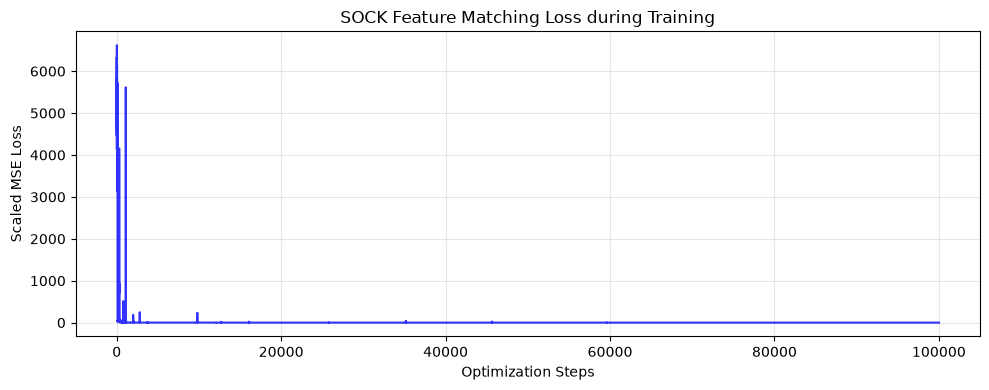

In [35]:
plot_training_loss(loss_hist)

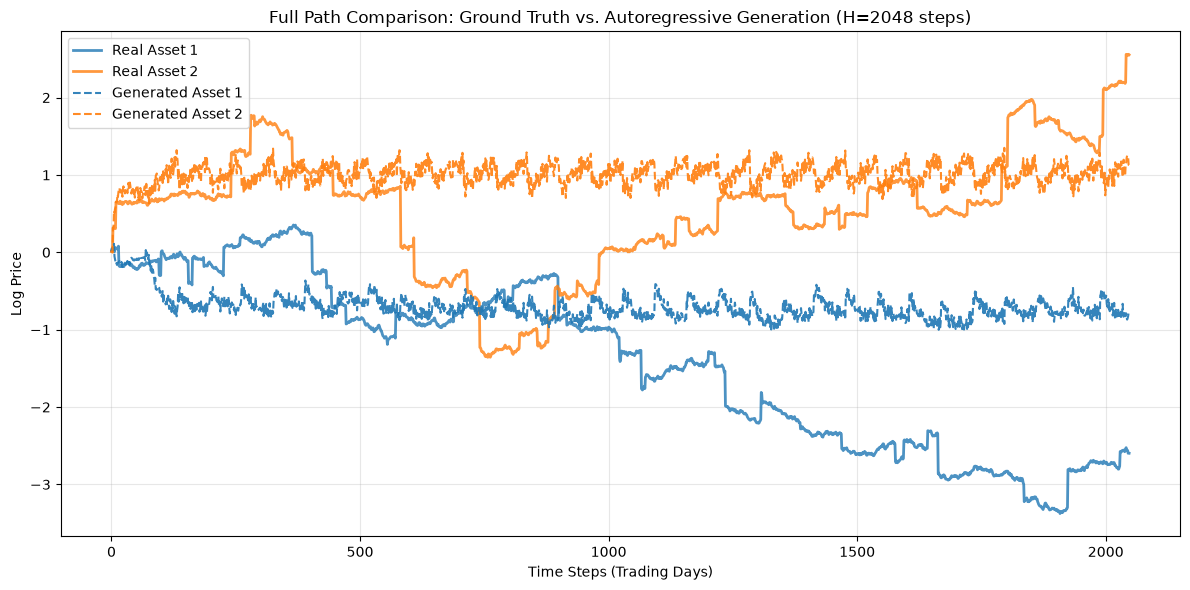

In [37]:
plot_full_autoregressive_rollout(gen, dataset, device, hist_path)